10.26 is the noiseless cycling time
sigma=0.0010, median(T)=1000.0, 95% CI=[748.0, 1000.0]
sigma=0.0012, median(T)=1000.0, 95% CI=[530.0, 1000.0]
sigma=0.0014, median(T)=1000.0, 95% CI=[392.0, 1000.0]
sigma=0.0016, median(T)=1000.0, 95% CI=[302.0, 1000.0]
sigma=0.0019, median(T)=1000.0, 95% CI=[224.0, 1000.0]
sigma=0.0022, median(T)=1000.0, 95% CI=[158.0, 1000.0]
sigma=0.0026, median(T)=1000.0, 95% CI=[116.0, 1000.0]
sigma=0.0030, median(T)=1000.0, 95% CI=[90.0, 1000.0]
sigma=0.0035, median(T)=718.0, 95% CI=[64.0, 1000.0]
sigma=0.0041, median(T)=528.0, 95% CI=[50.0, 1000.0]
sigma=0.0048, median(T)=400.0, 95% CI=[36.0, 1000.0]
sigma=0.0056, median(T)=298.0, 95% CI=[28.0, 1000.0]
sigma=0.0065, median(T)=218.0, 95% CI=[20.0, 1000.0]
sigma=0.0076, median(T)=172.0, 95% CI=[16.0, 1000.0]
sigma=0.0089, median(T)=126.0, 95% CI=[12.0, 1000.0]
sigma=0.0104, median(T)=94.0, 95% CI=[10.0, 1000.0]
sigma=0.0122, median(T)=74.0, 95% CI=[10.0, 1000.0]
sigma=0.0142, median(T)=62.0, 95% CI=[10.0, 1000.0

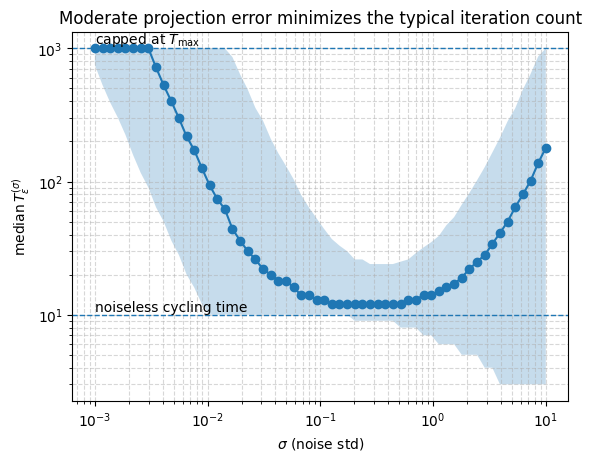

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def simulate_hitting_time(alpha, eps, sigma, s0, max_steps=5000, rng=None):
    """
    Simulate one trajectory of:
        s_{t+1} = s_t - alpha * (sign(s_t) + N(0, sigma^2))
    and return T = first t with |s_t| <= eps (capped at max_steps).
    """
    if rng is None:
        rng = np.random.default_rng()

    s = s0

    for t in range(max_steps):
        if abs(s) <= eps:
            return t
        noise = rng.normal(0.0, sigma)
        # s = s - alpha * (np.sign(s) + 0) # without noise: deterministic sign-GD, never hits [-eps, eps] for our choice of s0
        s = s - alpha * (np.sign(s) + noise)
    # censored at max_steps
    return max_steps

def estimate_hitting_time_stats(alpha, eps, s0,
                       sigmas, n_samples=1000,
                       max_steps=5000, seed=0):
    """
    For each sigma, estimate:
      - median(T)
      - central 95% interval of T
    """
    rng = np.random.default_rng(seed)
    medians = []
    q_low, q_high = [], []

    for sigma in sigmas:
        Ts = np.empty(n_samples, dtype=int)

        for i in range(n_samples):
            T = simulate_hitting_time(alpha, eps, sigma, s0,
                                    max_steps=max_steps, rng=rng)
            Ts[i] = T


        med = np.median(Ts)
        lo, hi = np.quantile(Ts, [0.025, 0.975])

        medians.append(med)
        q_low.append(lo); q_high.append(hi)

        print(
            f"sigma={sigma:.4f}, "
            f"median(T)={med:.1f}, "
            f"95% CI=[{lo:.1f}, {hi:.1f}]"
        )

    return (
        np.array(medians),
        np.array(q_low), np.array(q_high),
    )


if __name__ == "__main__":
    seed = 0

    alpha = 0.1 # step size in the sign updates
    eps   = alpha / 5.0 # target eps, choose it << alpha to ensure that the noiseless trajectory never hits [-eps, eps] and thus cycles indefinitely
    # choose s0 so that 0 is not eps-close to the grid s0 + alpha * Z (sign-gd never hits [-eps, eps])
    s0    = 10 * alpha + eps * 1.3
    print(abs(s0) / alpha, "is the noiseless cycling time")
    max_steps = 1_000
    n_samples = 10_000

    sigmas = np.logspace(-3, 1, 60)  # from 1e-3 to 10 on a log grid
    
    medians, q_low, q_high = estimate_hitting_time_stats(
                                                    alpha, eps, s0, sigmas, n_samples=n_samples, max_steps=max_steps, seed=seed
                                                )



    plt.figure()

    plt.fill_between(
        sigmas,
        q_low,
        q_high,
        alpha=0.25,
        linewidth=0
    )
    plt.plot(sigmas, medians, marker="o", linewidth=1.5)

    plt.xscale("log")
    plt.yscale("log")

    plt.xlabel(r"$\sigma$ (noise std)")
    plt.ylabel(r"$\mathrm{median}\, T_{\varepsilon}^{(\sigma)}$")

    plt.axhline(max_steps, linewidth=1.0, linestyle="--")
    plt.text(sigmas[0], max_steps, r"capped at $T_{\max}$", va="bottom")

    plt.axhline(int(abs(s0) / alpha), linewidth=1.0, linestyle="--")
    plt.text(sigmas[0], int(abs(s0) / alpha), r"noiseless cycling time", va="bottom")

    plt.title("Moderate projection error minimizes the typical iteration count")
    plt.grid(True, which="both", ls="--", alpha=0.5)

    out_dir = "./images"
    os.makedirs(out_dir, exist_ok=True)
    save_path = os.path.join(out_dir, f"fig4_sign_gd_hitting_time_stats_alpha{alpha:g}_eps{eps:g}_s0{s0:g}_steps{max_steps}_samples{n_samples}_seed{seed}.pdf")
    plt.savefig(save_path)

    plt.show()
